# Сборный проект-4

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

### Описание данных

Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).

В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ExpertAnnotations.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

## 1. Исследовательский анализ данных

Наш датасет содержит экспертные и краудсорсинговые оценки соответствия текста и изображения.

В файле с экспертными мнениями для каждой пары изображение-текст имеются оценки от трёх специалистов. Для решения задачи вы должны эти оценки агрегировать — превратить в одну. Существует несколько способов агрегации оценок, самый простой — голосование большинства: за какую оценку проголосовала большая часть экспертов (в нашем случае 2 или 3), та оценка и ставится как итоговая. Поскольку число экспертов меньше числа классов, может случиться, что каждый эксперт поставит разные оценки, например: 1, 4, 2. В таком случае данную пару изображение-текст можно исключить из датасета.

Вы можете воспользоваться другим методом агрегации оценок или придумать свой.

В файле с краудсорсинговыми оценками информация расположена в таком порядке:

1. Доля исполнителей, подтвердивших, что текст **соответствует** картинке.
2. Количество исполнителей, подтвердивших, что текст **соответствует** картинке.
3. Количество исполнителей, подтвердивших, что текст **не соответствует** картинке.

После анализа экспертных и краудсорсинговых оценок выберите либо одну из них, либо объедините их в одну по какому-то критерию: например, оценка эксперта принимается с коэффициентом 0.6, а крауда — с коэффициентом 0.4.

Ваша модель должна возвращать на выходе вероятность соответствия изображения тексту, поэтому целевая переменная должна иметь значения от 0 до 1.


In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
import torchvision
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.6.0+cu126
Torchvision version: 0.21.0+cu126


In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from ydata_profiling import ProfileReport
from pathlib import Path

import nltk
import re

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from PIL import Image

from transformers import BertTokenizer, BertModel

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

C:\Users\samou\practicum\my_env_tf\lib\site-packages\networkx\utils\backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [3]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU is available")
    print(torch.cuda.get_device_name(0)) # Выводит имя устройства GPU
else:
    print("GPU is not available")

True
GPU is available
NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
# Конфигурация
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 10

# Создаём список английских слов, которые могут указывать на нарушение законодательства
RESTRICTED_WORDS = [
    'child', 'kid', 'baby', 'teenager', 'schoolboy', 'schoolgirl', 'infant',
    'toddler', 'minor', 'youngster', 'youth', 'adolescent', 'juvenile', 'teenage', 'girl', 
    'boy', 'daughter', 'offspring', 'son', 'babe', 'bairn', 'bambino', 'brat', 'chick', 'cub', 
    'imp', 'innocent', 'lamb', 'moppet', 'nestling', 'nipper', 'shaver', 'sprout', 'squirt', 
    'stripling', 'suckling', 'tadpole', 'tot', 'tyke', 'urchin', 'anklebiter', 'gamin', 
    'gamine', 'kiddie', 'pubescent', 'small fry', 'young one'
]

# Настройка параметров отображения Pandas
pd.set_option('display.max_colwidth', None)

# Пути к данным
DATA_DIR = "C:/Users/samou/practicum/Search_by_images/datasets"
TRAIN_CSV = os.path.join(DATA_DIR, "train_dataset.csv")
CROWD_TSV = os.path.join(DATA_DIR, "CrowdAnnotations.tsv")
EXPERT_TSV = os.path.join(DATA_DIR, "ExpertAnnotations.tsv")
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMAGES_DIR = os.path.join(DATA_DIR, "test_images")
TEST_QUERIES_CSV = os.path.join(DATA_DIR, "test_queries.csv")

# Загрузка данных
train_df = pd.read_csv(TRAIN_CSV)
crowd_df = pd.read_csv(CROWD_TSV, sep='\t', header=None, names=['image', 'desc_id', 'crowd_score', 'num_yes', 'num_no'])
expert_df = pd.read_csv(EXPERT_TSV, sep='\t', header=None, names=['image', 'desc_id', 'e1', 'e2', 'e3'])

# Загрузка тестовых запросов
test_queries_df = pd.read_csv(TEST_QUERIES_CSV, sep='|', index_col=0)

# Переименуем столбец 'query_id' в 'desc_id' для совместимости
train_df.rename(columns={'query_id': 'desc_id'}, inplace=True)

In [5]:
display(train_df.tail())
train_df.info()

,image,desc_id,query_text
5817,757046028_ff5999f91b.jpg,2061144717_5b3a1864f0.jpg#2,A man in an ampitheater talking to a boy .
5818,799486353_f665d7b0f0.jpg,2196107384_361d73a170.jpg#2,a old man walks down the uncrowded road .
5819,909808296_23c427022d.jpg,2112921744_92bf706805.jpg#2,A dog stands on the side of a grassy cliff .
5820,929679367_ff8c7df2ee.jpg,3651971126_309e6a5e22.jpg#2,A blurry photo of two dogs .
5821,968081289_cdba83ce2e.jpg,2292406847_f366350600.jpg#2,A man rows his boat below .


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5822 non-null   object
 1   desc_id     5822 non-null   object
 2   query_text  5822 non-null   object
dtypes: object(3)
memory usage: 136.6+ KB


In [6]:
# Генерация отчёта
profile = ProfileReport(
    train_df,
    vars={'num': {'low_categorical_threshold': 10}},  # Настройки для числовых переменных
    title="Отчёт о данных для задачи поиска изображений по тексту",
    explorative=True
)

# Отображение отчёта в окне
profile.to_widgets()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render widgets:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
crowd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   image        47830 non-null  object 
 1   desc_id      47830 non-null  object 
 2   crowd_score  47830 non-null  float64
 3   num_yes      47830 non-null  int64  
 4   num_no       47830 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ MB


In [8]:
# Генерация отчёта
profile = ProfileReport(
    crowd_df,
    vars={'num': {'low_categorical_threshold': 10}},  # Настройки для числовых переменных
    title="Отчёт о данных для задачи поиска изображений по тексту",
    explorative=True
)

# Отображение отчёта в окне
profile.to_widgets()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render widgets:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
display(expert_df.tail())
expert_df.info()

,image,desc_id,e1,e2,e3
5817,997722733_0cb5439472.jpg,2981702521_2459f2c1c4.jpg#2,1,1,1
5818,997722733_0cb5439472.jpg,2985679744_75a7102aab.jpg#2,1,1,1
5819,997722733_0cb5439472.jpg,3150742439_b8a352e1e0.jpg#2,1,1,2
5820,997722733_0cb5439472.jpg,3375070563_3c290a7991.jpg#2,1,1,1
5821,997722733_0cb5439472.jpg,486917990_72bd4069af.jpg#2,3,3,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   image    5822 non-null   object
 1   desc_id  5822 non-null   object
 2   e1       5822 non-null   int64 
 3   e2       5822 non-null   int64 
 4   e3       5822 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 227.5+ KB


In [10]:
# Генерация отчёта
profile = ProfileReport(
    expert_df,
    vars={'num': {'low_categorical_threshold': 10}},  # Настройки для числовых переменных
    title="Отчёт о данных для задачи поиска изображений по тексту",
    explorative=True
)

# Отображение отчёта в окне
profile.to_widgets()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render widgets:   0%|          | 0/1 [00:00<?, ?it/s]

Просмотр примера предоставленных изображений:

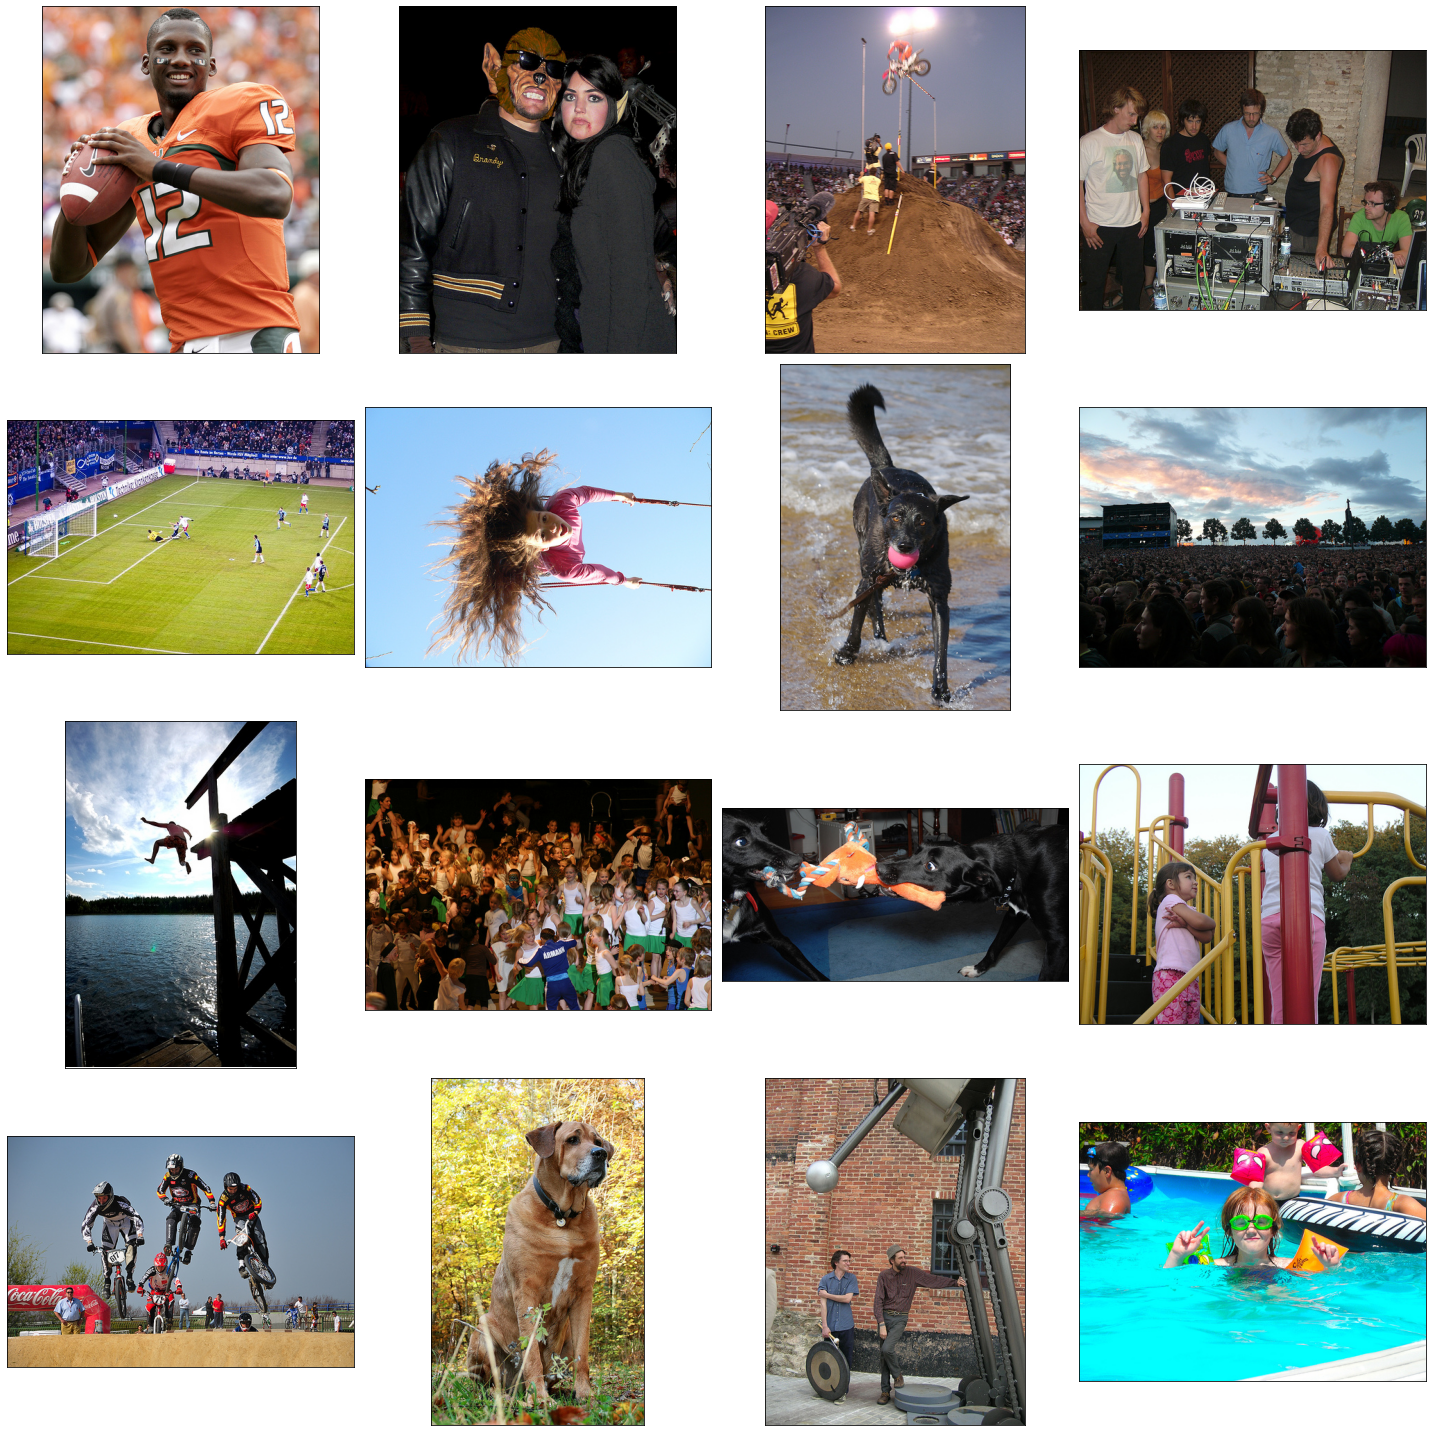

In [11]:
samples_train = list(train_df['image'].sample(8))
samples_test = list(test_queries_df['image'].sample(8))

fig = plt.figure(figsize=(20,20))
for i in range(8):
    fig.add_subplot(4, 4, i+1)
    image = Image.open(Path(DATA_DIR, 'train_images', samples_train[i]))
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
for i in range(8):
    fig.add_subplot(4, 4, i+9)
    image = Image.open(Path(DATA_DIR, 'test_images', samples_test[i]))
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

### Промежуточный вывод:

* train_df - пропуски отсутствуют, данные соответствуют описанию.
* crowd_df - столбец `crowd_score` содержит большое количество нулей (87,7 %). В этой связке столбцы `num_yes` и `num_no` имеют дисбаланс (в значениях 0 и 3 соответственно). Т.к. среднее вытекает из этих столбцов, наблюдается высокая корреляция между признаками. Пропуски отсутствуют.
* expert_df - у первого и второго экспертов наблюдается дисбаланс в сторону оценки 1 (изображение и запрос совершенно не соответствуют друг другу), у третьего оценки более равномерны. Также наблюдается умеренная корреляция между признаками. Пропуски отсутствуют.

Большинство оценок в обоих методах оценки приближены к низкому соответствию описания изображению, что может сказаться на качестве обучаемой модели.

Объединим датасеты для дальнейшего анализа и работы. Чтобы учесть все оценки людей и экспертов, объединение обоих датасетов осуществим с флагом `outer`. Таким образом у части пар будут оценки экспертов (как более надёжные), для некоторых оценки людей, для остальных смешанная оценка. 

In [12]:
final_df = []

final_df = pd.merge(expert_df, crowd_df, how='outer', on=['image', 'desc_id'])

final_df.head()

,image,desc_id,e1,e2,e3,crowd_score,num_yes,num_no
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,NaN,NaN,NaN,1.0,3.0,0.0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,NaN,NaN,NaN,0.0,0.0,3.0
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,NaN,NaN,NaN,0.0,0.0,3.0
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,NaN,NaN,NaN,0.0,0.0,3.0
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,NaN,NaN,NaN,0.0,0.0,3.0


Далее проведём сдвиг и преобразование оценок экспертов (вместо от 1 до 4 будет от 0 до 3) с учётом их согласованности в вероятность соответствия изображения и описания. Если эксперты сильно расходятся во мнениях, это может указывать на то, что соответствие между изображением и описанием неоднозначное. Можно учитывать это при преобразовании оценок в вероятности. Например, снижать вероятность, если стандартное отклонение оценок экспертов высоко.

Поскольку в ходе EDA-анализа было выявлено, что подавляющее большинство оценок краудсорсинга равно нулю (87 % от всего датасета `crowd_df`), то введём условие, согласно которому в случае нулевой краудсорсинговой оценки приоритетным выбором будет преобразованная экспертная оценка. Если оценка экспертов будет отсутствовать, будем брать любую краудсорсинговую оценку. Если же обе оценки релевантны, то введём веса для оценок. Перевес сделаем в сторону экспертных оценок.

In [13]:
# Сдвигаем оценки экспертов на -1, чтобы диапазон стал [0, 3]
final_df[['e1', 'e2', 'e3']] = final_df[['e1', 'e2', 'e3']] - 1

# Вычисляем среднее и стандартное отклонение сдвинутых оценок экспертов
final_df['expert_avg'] = final_df[['e1', 'e2', 'e3']].mean(axis=1)
final_df['expert_std'] = final_df[['e1', 'e2', 'e3']].std(axis=1)

# Функция для преобразования с учетом стандартного отклонения
def map_to_probability_with_std(row):
    avg = row['expert_avg']
    std = row['expert_std']

    # Если оценки экспертов отсутствуют, используем crowd_score
    if pd.isna(avg) or pd.isna(std):
        return row['crowd_score']

    # Чем выше стандартное отклонение, тем ниже вероятность
    probability = (avg / 3) * (1 - std / 3)  # Теперь std и avg в диапазоне [0, 3]
    return max(0, min(1, probability))  # Обрезаем значения до [0, 1]

# Применяем функцию
final_df['expert_probability'] = final_df.apply(map_to_probability_with_std, axis=1)

# Определяем итоговую оценку с весами
w1 = 0.3  # Вес для crowd_score
w2 = 0.7  # Вес для expert_probability

final_df['final_score'] = final_df.apply(
    lambda x: (w1 * x['crowd_score'] + w2 * x['expert_probability']) if x['crowd_score'] > 0 else x['expert_probability'],
    axis=1
)

In [14]:
final_df.head(20)

,image,desc_id,e1,e2,e3,crowd_score,num_yes,num_no,expert_avg,expert_std,expert_probability,final_score
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,NaN,NaN,NaN,1.000000,3.0,0.0,NaN,NaN,1.000000,1.000000
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
5,1056338697_4f7d7ce270.jpg,2204550058_2707d92338.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
6,1056338697_4f7d7ce270.jpg,2224450291_4c133fabe8.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
7,1056338697_4f7d7ce270.jpg,2248487950_c62d0c81a9.jpg#2,NaN,NaN,NaN,0.333333,1.0,2.0,NaN,NaN,0.333333,0.333333
8,1056338697_4f7d7ce270.jpg,2307118114_c258e3a47e.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000
9,1056338697_4f7d7ce270.jpg,2309860995_c2e2a0feeb.jpg#2,NaN,NaN,NaN,0.000000,0.0,3.0,NaN,NaN,0.000000,0.000000


In [15]:
display(final_df['final_score'].isna().value_counts())
final_df['final_score'].describe()

final_score
False    51323
Name: count, dtype: int64

count    51323.000000
mean         0.076754
std          0.206663
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: final_score, dtype: float64

In [16]:
final_df = pd.merge(train_df, final_df[['image', 'desc_id', 'final_score']], how='outer', on=['image', 'desc_id'])

to_fill = train_df[train_df['query_text'].notna()]

def fill_text(row) -> object:


    if pd.isnull(row['query_text']):
        texts = to_fill[to_fill['desc_id'] == row['desc_id']]['query_text']
        if len(texts) > 0:
            row['query_text'] = texts.iloc[0]

    return row

final_df = final_df.apply(fill_text, axis=1)

display(final_df.head())
final_df.info()

,image,desc_id,query_text,final_score
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,"A woman is signaling is to traffic , as seen from behind .",1.0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,A boy in glasses is wearing a red shirt .,0.0
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,A young boy holds onto a blue handle on a pier .,0.0
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,"A woman wearing black clothes , a purple scarf , and a pink hat is riding a bike .",0.0
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,An older woman with blond hair rides a bicycle down the street .,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   image        51323 non-null  object 
 1   desc_id      51323 non-null  object 
 2   query_text   50214 non-null  object 
 3   final_score  51323 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.6+ MB


После добавления текстов, оказалось что для части query_id нет описаний, удалим такие записи.

In [17]:
final_df = final_df.dropna()
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50214 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   image        50214 non-null  object 
 1   desc_id      50214 non-null  object 
 2   query_text   50214 non-null  object 
 3   final_score  50214 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.9+ MB


### Промежуточные выводы:

* Выбрали метод и агрегировали оценки. 
* Объединили оценки с обучающим набором данных.
* Заполнили пропуски.
* Удалили незаполненные пропуски.

## 2. Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.

В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

> This image is unavailable in your country in compliance with local laws
>

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

Также удалим строки, где отсутствует описание изображения, т.к. изображение в такой строке может оказаться нарушающим законодательство.

In [18]:
lemmatize = nltk.WordNetLemmatizer()

def get_lemmas(text) -> list:


    text = re.sub('[^a-zA-Z]', ' ', text).lower() # удаляем неалфавитные символы, приводим к нижнему регистру
    text = nltk.word_tokenize(text, language = 'english') # токенизируем слова
    text = [lemmatize.lemmatize(word) for word in text] # лемматирзируем слова

    return text

def cleaning(row) -> object:


    text = get_lemmas(row['query_text'])
    if [i for i in text if i in RESTRICTED_WORDS]:
        row['to_block'] = 1
    else:
        row['to_block'] = 0

    return row

final_df = final_df.apply(cleaning, axis=1)

In [19]:
final_df.head()

,image,desc_id,query_text,final_score,to_block
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,"A woman is signaling is to traffic , as seen from behind .",1.0,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,A boy in glasses is wearing a red shirt .,0.0,1
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,A young boy holds onto a blue handle on a pier .,0.0,1
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,"A woman wearing black clothes , a purple scarf , and a pink hat is riding a bike .",0.0,0
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,An older woman with blond hair rides a bicycle down the street .,0.0,0


In [20]:
bad_images = set(list(final_df[final_df['to_block'] == 1]['desc_id'].apply(lambda x: x[:-2].lower()).unique()))


print('Всего "плохих" изображений:',len(bad_images))

Всего "плохих" изображений: 293


Проверим, какие запросы оказались заблокированы:

In [21]:
print(final_df[final_df['to_block'] == 1]['query_text'].sample(10).unique())

['Children play in a water spray .'
 'A young boy dressed in a black hoodie crawling through a large , white tube .'
 'Two girls walking down the street .'
 'Little girl in bare feet sitting in a circle .'
 'A girl walks toward a herd of sheep in the distance .'
 'Four small children sit on tall stools at a restaurant bar .'
 'People at park sitting on benches and a woman taking care of her child in the stroller .'
 'A boy takes a flying leap into the water .'
 'A little boy shakes the snow off of a tree .']


Проверим картинки, которые попали под блокировку:

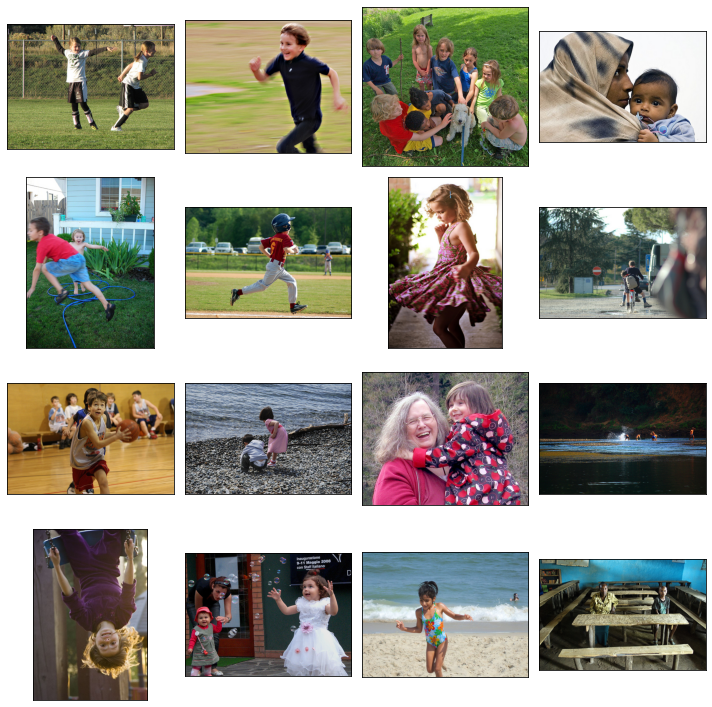

In [22]:
samples = list(final_df[final_df['to_block'] == 1]['desc_id'].sample(16))
samples = [i[:-2] for i in samples]

fig = plt.figure(figsize=(10,10))
for i in range(16):
    fig.add_subplot(4, 4, i+1)
    image = Image.open(Path(DATA_DIR, 'train_images', samples[i]))
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

Судя по всему, фотографии отобранны в основном корректно. В то же время необходимо учесть факт, что *не все описания подходят к изображению.* Определим среднее значение оценки соответствия данных пар и выберем те изображения, оценка соответствия которых выше. Из этого списка вычленим уникальные id изображений и удалим из строки с этими id из `final_df`.

In [23]:
# Вычисляем средний final_score для строк, где to_block = 1
threshold = final_df[final_df['to_block'] == 1]['final_score'].mean()
print(f"Средний final_score для заблокированных строк: {threshold}")

# Фильтруем изображения, где final_score выше порога
high_score_images = final_df[(final_df['to_block'] == 1) & (final_df['final_score'] > threshold)]['desc_id'].str[:-2].unique()

# Удаляем строки с этими изображениями из final_df
final_df = final_df[~final_df['desc_id'].str[:-2].isin(high_score_images)]
final_df.drop(columns='to_block', inplace=True, errors='ignore')
final_df.reset_index(inplace=True, drop=True)

display(final_df.head(), test_queries_df.head())
final_df.info()
print('-' * 100)
test_queries_df.info()

Средний final_score для заблокированных строк: 0.05347096299036689


,image,desc_id,query_text,final_score
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,"A woman is signaling is to traffic , as seen from behind .",1.0
1,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,"A woman wearing black clothes , a purple scarf , and a pink hat is riding a bike .",0.0
2,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,An older woman with blond hair rides a bicycle down the street .,0.0
3,1056338697_4f7d7ce270.jpg,2204550058_2707d92338.jpg#2,A woman wearing a white glove peers over the crowd .,0.0
4,1056338697_4f7d7ce270.jpg,2224450291_4c133fabe8.jpg#2,A man taking a picture with a silver camera .,0.0


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at each other .,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each other .,1177994172_10d143cb8d.jpg


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36171 entries, 0 to 36170
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   image        36171 non-null  object 
 1   desc_id      36171 non-null  object 
 2   query_text   36171 non-null  object 
 3   final_score  36171 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB
----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_id    500 non-null    object
 1   query_text  500 non-null    object
 2   image       500 non-null    object
dtypes: object(3)
memory usage: 15.6+ KB


### Промежуточный вывод:

Произведена проверка данных на содержание запрещенных слов. Датасет очищен.

## 3. Векторизация изображений

Перейдём к векторизации изображений.

Самый примитивный способ — прочесть изображение и превратить полученную матрицу в вектор. Такой способ нам не подходит: длина векторов может быть сильно разной, так как размеры изображений разные. Поэтому стоит обратиться к свёрточным сетям: они позволяют "выделить" главные компоненты изображений. Как это сделать? Нужно выбрать какую-либо архитектуру, например ResNet-18, посмотреть на слои и исключить полносвязные слои, которые отвечают за конечное предсказание. При этом можно загрузить модель данной архитектуры, предварительно натренированную на датасете ImageNet.

In [24]:
# Загружаем предобученную модель ResNet-50 и переносим её на GPU (если доступно)
resnet50 = models.resnet50(pretrained=True)
resnet50 = torch.nn.Sequential(*list(resnet50.children())[:-1])
resnet50 = resnet50.to(device)  # Переносим модель на GPU
resnet50.eval()  # Переводим модель в режим оценки

# Определяем преобразования для изображений
preprocess = transforms.Compose([
    transforms.Resize(256),  # Изменяем размер изображения
    transforms.CenterCrop(224),  # Обрезаем центр изображения
    transforms.ToTensor(),  # Преобразуем в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализуем
])

# Функция для векторизации изображения
def vectorize_image(image_path, model):
    # Загружаем изображение
    image = Image.open(image_path).convert('RGB')
    
    # Применяем преобразования
    input_tensor = preprocess(image)
    
    # Добавляем batch dimension и переносим на GPU
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    # Пропускаем изображение через модель
    with torch.no_grad():  # Отключаем вычисление градиентов
        output = model(input_batch)
    
    # Преобразуем выход в вектор (убираем batch dimension) и переносим на CPU
    vector = output.squeeze().cpu()
    
    return vector


C:\Users\samou\practicum\my_env_tf\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\samou\practicum\my_env_tf\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
# Вычленяем уникальные изображения
unique_images = final_df['image'].unique()
print(f"Уникальных изображений: {len(unique_images)}")

# Векторизуем уникальные изображения
image_vectors = []
for image_path in unique_images:
    full_image_path = os.path.join(TRAIN_IMAGES_DIR, image_path)
    vector = vectorize_image(full_image_path, resnet50)
    image_vectors.append(vector.numpy())  # Преобразуем тензор в numpy array

# Создаём DataFrame с векторами уникальных изображений
image_vectors_df = pd.DataFrame(image_vectors, columns=[f"feature_{i}" for i in range(2048)])
image_vectors_df['image'] = unique_images

# Объединяем с финальным датасетом
final_df = pd.merge(final_df, image_vectors_df, on='image', how='left')

Уникальных изображений: 1000


## 4. Векторизация текстов

Следующий этап — векторизация текстов. Вы можете поэкспериментировать с несколькими способами векторизации текстов:

- tf-idf
- word2vec
- \*трансформеры (например Bert)

\* — если вы изучали трансформеры в спринте Машинное обучение для текстов.

В нашей задаче будем использовать пулинг по всем токенам, так как он подходит для задач, где важно учитывать контекст всех токенов (например, семантический поиск, кластеризация текстов). Использование пулинга (например, среднее или максимальное значение) по всем выходным токенам (кроме паддингов) позволяет получить более общее представление текста, учитывая информацию из всех токенов последовательности.

Преимущества:

* Учет контекста: Все токены вносят вклад в итоговый эмбеддинг, что может быть полезно для длинных текстов или сложных контекстов.

* Устойчивость: Пулинг менее зависим от конкретного токена (например, CLS), что делает его более универсальным.

* Качество: Многие исследования показывают, что пулинг по всем токенам часто дает более качественные эмбеддинги, особенно для моделей, которые не обучались на задаче NSP.


In [26]:
# Загружаем предобученный токенизатор и модель BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Переводим модель в режим оценки (не требуется градиент)
model.eval()

# Переносим модель на GPU, если доступно
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Функция для векторизации текста с использованием пулинга по всем токенам
def vectorize_text(text, model, tokenizer, device):
    # Токенизируем текст
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
    
    # Переносим входные данные на GPU (если доступно)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    attention_mask = inputs['attention_mask']
    
    # Пропускаем текст через модель
    with torch.no_grad():  # Отключаем вычисление градиентов
        outputs = model(**inputs)
    
    # Извлекаем последний скрытый слой (эмбеддинги всех токенов)
    last_hidden_state = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)
    
    # Убираем влияние паддинг-токенов
    attention_mask = attention_mask.unsqueeze(-1)  # (batch_size, seq_len, 1)
    masked_hidden_state = last_hidden_state * attention_mask  # Умножаем на маску, чтобы обнулить паддинги
    
    # Вычисляем среднее значение по всем токенам (кроме паддингов)
    sum_hidden_states = masked_hidden_state.sum(dim=1)  # Суммируем по оси токенов (batch_size, hidden_size)
    sum_mask = attention_mask.sum(dim=1)  # Сумма масок (batch_size, 1)
    mean_hidden_state = sum_hidden_states / sum_mask  # Среднее значение (batch_size, hidden_size)
    
    return mean_hidden_state.squeeze().cpu().numpy()  # Преобразуем в numpy array и убираем batch_size

In [27]:
# Вычленяем уникальные текстовые описания
unique_texts = final_df['query_text'].unique()
print(f"Уникальных текстовых описаний: {len(unique_texts)}")

# Векторизуем уникальные текстовые описания
text_vectors = []
for text in unique_texts:
    vector = vectorize_text(text, model, tokenizer, device)
    text_vectors.append(vector)  # Добавляем вектор в список

# Создаём DataFrame с векторами уникальных текстов
text_vectors_df = pd.DataFrame(text_vectors, columns=[f"text_feature_{i}" for i in range(768)])  # BERT-base имеет 768-мерные эмбеддинги
text_vectors_df['query_text'] = unique_texts

# Объединяем с финальным датасетом
final_df = pd.merge(final_df, text_vectors_df, on='query_text', how='left')

Уникальных текстовых описаний: 694


## 5. Объединение векторов

Подготовим данные для обучения: объедините векторы изображений и векторы текстов с целевой переменной.

In [28]:
# Выделяем векторы изображений и текстов
image_features = final_df[[f"feature_{i}" for i in range(2048)]].values
text_features = final_df[[f"text_feature_{i}" for i in range(768)]].values

# Объединяем векторы изображений и текстов
X = np.hstack((image_features, text_features))  # Объединяем по горизонтали
y = final_df['final_score'].values  # Целевая переменная

# Проверяем размерности
print(f"Размерность объединённых признаков (X): {X.shape}")
print(f"Размерность целевой переменной (y): {y.shape}")

# Сохраняем данные в файл
np.savez("dataset_for_training.npz", X=X, y=y)
print("Данные для обучения сохранены в файл dataset_for_training.npz")

Размерность объединённых признаков (X): (36171, 2816)
Размерность целевой переменной (y): (36171,)
Данные для обучения сохранены в файл dataset_for_training.npz


### Промежуточный вывод:
Признаки и цели готовы, можно обучать модели.

## 6. Обучение модели предсказания соответствия

Для обучения разделите датасет на тренировочную и тестовую выборки. Простое случайное разбиение не подходит: нужно исключить попадание изображения и в обучающую, и в тестовую выборки.
Для того чтобы учесть изображения при разбиении, можно воспользоваться классом [GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html) из библиотеки sklearn.model_selection.

Код ниже разбивает датасет на тренировочную и тестовую выборки в пропорции 7:3 так, что строки с одинаковым значением 'group_column' будут содержаться либо в тестовом, либо в тренировочном датасете.

```
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=42)
train_indices, test_indices = next(gss.split(X=df.drop(columns=['target']), y=df['target'], groups=df['group_column']))
train_df, test_df = df.loc[train_indices], df.loc[test_indices]

```

Для задачи регрессии (предсказания оценки) подходящей метрикой является Mean Squared Error (MSE) или Root Mean Squared Error (RMSE).

Выбираем RMSE по следующим причинам:

* RMSE измеряет среднее отклонение предсказанных значений от истинных.
* Она имеет ту же размерность, что и целевая переменная, что делает её интерпретируемой.
* RMSE сильнее штрафует большие ошибки, что полезно для задач, где важно минимизировать крупные отклонения.

In [29]:
# Создаём объект GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)

# Разделяем данные на тренировочную и тестовую выборки
# В качестве групп используем столбец 'image'
train_indices, test_indices = next(gss.split(X=final_df.drop(columns=['final_score']), y=final_df['final_score'],
                                             groups=final_df['image']))

# Создаём тренировочный и тестовый датафреймы
train_df = final_df.loc[train_indices]
alpha_test_df = final_df.loc[test_indices]

# Проверяем размеры выборок
print(f"Размер тренировочной выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(alpha_test_df)}")

# Проверяем, что изображения не пересекаются между выборками
train_images = set(train_df['image'].unique())
test_images = set(alpha_test_df['image'].unique())
common_images = train_images.intersection(test_images)
print(f"Количество общих изображений между выборками: {len(common_images)}")

Размер тренировочной выборки: 25155
Размер тестовой выборки: 11016
Количество общих изображений между выборками: 0


In [30]:
# Разделение данных
X_train, X_val, y_train, y_val = train_test_split(
    train_df.drop(columns=['final_score', 'image', 'desc_id', 'query_text']), 
    train_df['final_score'], 
    test_size=0.2, 
    random_state=42
)

X_test = alpha_test_df.drop(columns=['final_score', 'image', 'desc_id', 'query_text'])
y_test = alpha_test_df['final_score']

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (20124, 2816)
Размер валидационной выборки: (5031, 2816)
Размер тестовой выборки: (11016, 2816)


### DummyRegressor

In [31]:
# Создаем бейзлайн-модель, которая предсказывает среднее значение целевой переменной
baseline_model = DummyRegressor(strategy="mean")

# Обучаем модель на обучающих данных
baseline_model.fit(X_train, y_train)

# Предсказания на валидационной выборке
y_pred_dummy = baseline_model.predict(X_val)

# Функция для вычисления MRSE (RMSE)
def mrse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# MRSE на валидационной выборке
mrse_dummy_val = mrse(y_val, y_pred_dummy)
print(f"MRSE DummyRegressor на валидационной выборке: {mrse_dummy_val:.4f}")

MRSE DummyRegressor на валидационной выборке: 0.2111


### Линейная регрессия

In [32]:
# Обучение линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Предсказание на валидационной выборке
y_pred_linear = linear_model.predict(X_val)

# Функция для вычисления MRSE (RMSE)
def mrse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# MRSE на валидационной выборке
mrse_linear_val = mrse(y_val, y_pred_linear)
print(f"MRSE линейной регрессии на валидационной выборке: {mrse_linear_val:.4f}")

MRSE линейной регрессии на валидационной выборке: 0.2071


### Полносвязная нейронная сеть

In [33]:
# Определение модели
class ImprovedNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 2816),
            nn.ReLU(),
            nn.LayerNorm(2816),
            nn.Dropout(0.5),  
            nn.Linear(2816, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.5),  
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.layers(x)

# Подготовка данных
# Преобразуем DataFrame/Series в массивы NumPy
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# Создание DataLoader для тренировочных и валидационных данных
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) 

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Создание DataLoader для тестовых данных
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # batch_size можно изменить

# Инициализация модели
input_size = X_train.shape[1]
improved_model = ImprovedNeuralNetwork(input_size).to(device)

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(improved_model.parameters(), lr=1e-4, weight_decay=1e-5)  
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# Ранняя остановка
best_loss = float('inf')
patience = 50
trigger_times = 0

# Обучение модели
epochs = 200  
for epoch in range(epochs):
    improved_model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = improved_model(batch_X)
        loss = criterion(outputs, batch_y.unsqueeze(1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()  

    # Вычисляем среднюю потерю на тренировочной выборке
    train_loss /= len(train_loader)

    # Валидация
    improved_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_outputs = improved_model(batch_X)
            val_loss += criterion(val_outputs, batch_y.unsqueeze(1)).item()

    # Вычисляем среднюю потерю на валидационной выборке
    val_loss /= len(val_loader)

    # Обновляем learning rate
    scheduler.step(val_loss)

    # Выводим информацию каждые 20 эпох
    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Ранняя остановка
    if val_loss < best_loss:
        best_loss = val_loss
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Ранняя остановка")
            break

# Оценка модели на валидационной выборке
improved_model.eval()
y_pred_val = []
with torch.no_grad():
    for batch_X, _ in val_loader:
        val_outputs = improved_model(batch_X)
        y_pred_val.extend(val_outputs.cpu().numpy())

# Вычисляем MRSE (RMSE) на валидационной выборке
mrse_nn_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"MRSE на валидационной выборке: {mrse_nn_val:.4f}")

Эпоха 20, Train Loss: 0.0400, Val Loss: 0.0396
Эпоха 40, Train Loss: 0.0376, Val Loss: 0.0391
Эпоха 60, Train Loss: 0.0367, Val Loss: 0.0392
Эпоха 80, Train Loss: 0.0367, Val Loss: 0.0392
Ранняя остановка
MRSE на валидационной выборке: 0.1978


### Промежуточный вывод:

Лучшая метрика у нейроести.

### Прогон на тестовых данных

In [34]:
# Оценка модели на тестовых данных (только если валидация прошла успешно)
if mrse_nn_val < 0.25:  # Пример порога для перехода к тестированию
    improved_model.eval()
    y_pred_test = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            test_outputs = improved_model(batch_X)
            y_pred_test.extend(test_outputs.cpu().numpy())
    
    # Вычисляем MRSE (RMSE) на тестовых данных
    mrse_test = mrse(y_test, y_pred_test)
    print(f"MRSE на тестовых данных: {mrse_test:.4f}")
else:
    print("Модель не прошла валидацию. Не переходим к тестированию.")

MRSE на тестовых данных: 0.2046


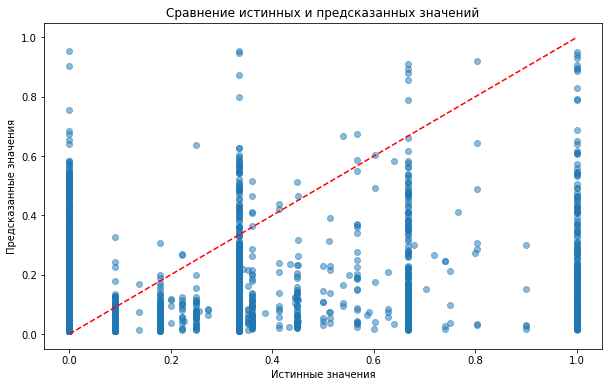

In [35]:
# Сравним предсказанные и истинные значения
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Линия идеальных предсказаний
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение истинных и предсказанных значений")
plt.show()

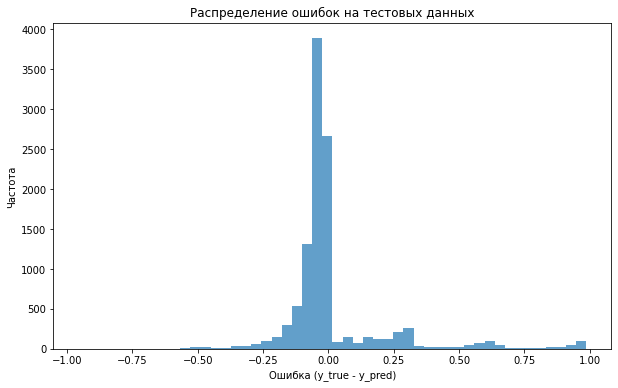

In [36]:
# Преобразуем y_pred_test в плоский массив
y_pred_test = np.array(y_pred_test).flatten()

# Вычисляем ошибки
errors = y_test - y_pred_test

# Строим гистограмму
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50, alpha=0.7)
plt.xlabel("Ошибка (y_true - y_pred)")
plt.ylabel("Частота")
plt.title("Распределение ошибок на тестовых данных")
plt.show()

### Промежуточный вывод:

Лучше всего с предсказаниями справилась нейросеть. Однако, подтверждается предположение, что данных для обучения недостаточно (на диаграмме "Сравнение истинных и предсказанных значений" заметен перекос в сторону преуменьшения прогноза, т.к. околонулевых оценок на порядок больше). В то же время на "нулевых" оценках модель также склонна завышать результат.


## 7. Тестирование модели

Настало время протестировать модель. Для этого получите эмбеддинги для всех тестовых изображений из папки `test_images`, выберите случайные 10 запросов из файла `test_queries.csv` и для каждого запроса выведите наиболее релевантное изображение. Сравните визуально качество поиска.

In [37]:
def find_and_display_images(query_text, test_queries_df, model, device, tokenizer, bert_model, image_model, top_k=5):
    """
    Находит топ-K изображений, наиболее подходящих для текстового запроса, и отображает их в один ряд.

    Параметры:
        query_text (str): Текстовое описание.
        test_queries_df (pd.DataFrame): DataFrame с тестовыми запросами.
        model (nn.Module): Обученная модель для предсказания релевантности.
        device (torch.device): Устройство для вычислений (CPU или GPU).
        tokenizer: Токенизатор для текста.
        bert_model: Модель BERT для векторизации текста.
        image_model: Модель для векторизации изображений.
        top_k (int): Количество изображений для возврата.
    """
    # Проверка на запрещенные слова
    
    lemmas = get_lemmas(query_text)
    if any(word in lemmas for word in RESTRICTED_WORDS):
        print(f"Запрос: {query_text}")
        print("This image is unavailable in your country in compliance with local laws.")
        return

    # Векторизация текста запроса
    query_vector = vectorize_text(query_text, bert_model, tokenizer, device)

    # Список для хранения результатов (image_path, score)
    results = []

    # Уникальные изображения из test_queries_df
    unique_images = test_queries_df['image'].unique()

    for image in unique_images:
        # Полный путь к изображению
        image_path = os.path.join(TEST_IMAGES_DIR, image)

        # Векторизация изображения
        image_vector = vectorize_image(image_path, image_model)

        # Объединение векторов текста запроса и изображения
        query_tensor = torch.tensor(query_vector, dtype=torch.float32).to(device)
        image_tensor = torch.tensor(image_vector, dtype=torch.float32).to(device)
        combined_vector = torch.cat([query_tensor, image_tensor], dim=0).unsqueeze(0)

        # Предсказание релевантности
        with torch.no_grad():
            combined_vector = combined_vector.to(device) 
            score = model(combined_vector).item()

        # Добавляем результат в список
        results.append((image_path, score))

    # Сортируем результаты по убыванию вероятности
    results.sort(key=lambda x: x[1], reverse=True)

    # Выводим запрос
    print(f"Запрос: {query_text}")

    # Создаем фигуру для отображения изображений в один ряд
    plt.figure(figsize=(15, 5))  

    # Отображаем топ-K изображений
    for i, (image_path, score) in enumerate(results[:top_k], 1):
        # Открываем изображение с помощью PIL
        img = Image.open(image_path)

        # Добавляем изображение в ряд
        plt.subplot(1, top_k, i)
        plt.imshow(img)
        plt.title(f"Вероятность: {score:.4f}")
        plt.axis('off')  # Скрываем оси

    # Показываем все изображения
    plt.tight_layout()  # Убираем наложение подписей
    plt.show()

    print("-" * 50)  # Разделитель между запросами

In [38]:
samples = test_queries_df.sample(10)
text_test = list(samples['query_text'])
text_test

['I child slides into a wading pool full of water while an adult tosses a bucket of water on them .',
 'A dog jumping for a tennis ball near an ocean',
 'A group of women wearing red all rally together .',
 'a man leans against a large robot .',
 'A large gray bird begins to land in the water .',
 "A little girl with her hands in the air is sitting on a man 's back while he is laying on a blanket .",
 'While holding tight to the ball , the man in red socks is getting tackled .',
 'An adult male wearing a backpack walks and looks to the left .',
 'Costumed performers stand onstage with their arms outstretched .',
 'Kids in bathing suits with water splashing around them .']

Запрос: I child slides into a wading pool full of water while an adult tosses a bucket of water on them .
This image is unavailable in your country in compliance with local laws.


C:\Users\samou\AppData\Local\Temp\ipykernel_36968\2163930097.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image_tensor = torch.tensor(image_vector, dtype=torch.float32).to(device)


Запрос: A dog jumping for a tennis ball near an ocean


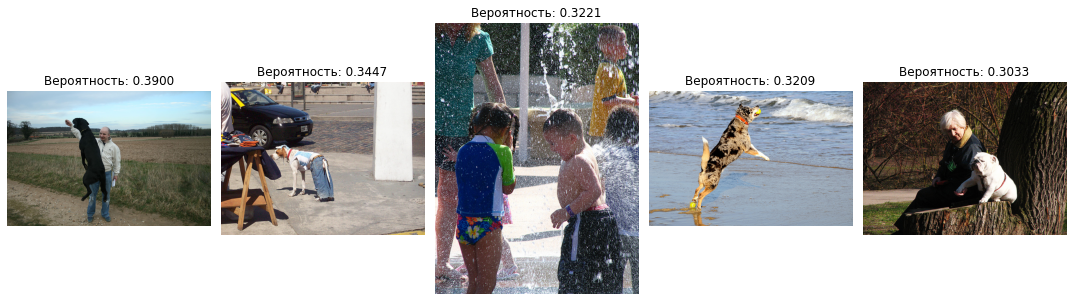

--------------------------------------------------
Запрос: A group of women wearing red all rally together .


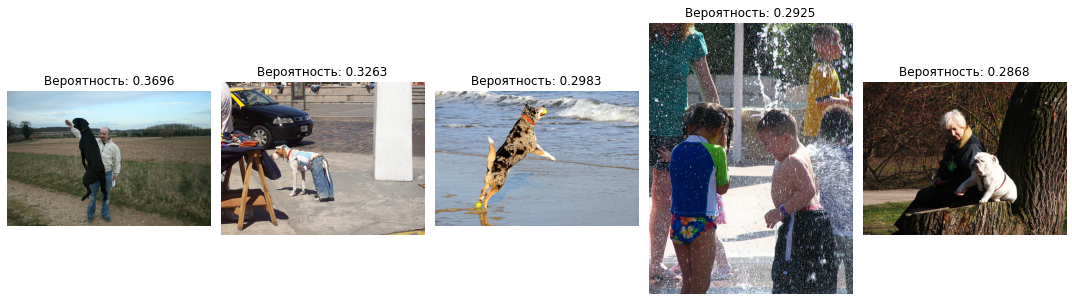

--------------------------------------------------
Запрос: a man leans against a large robot .


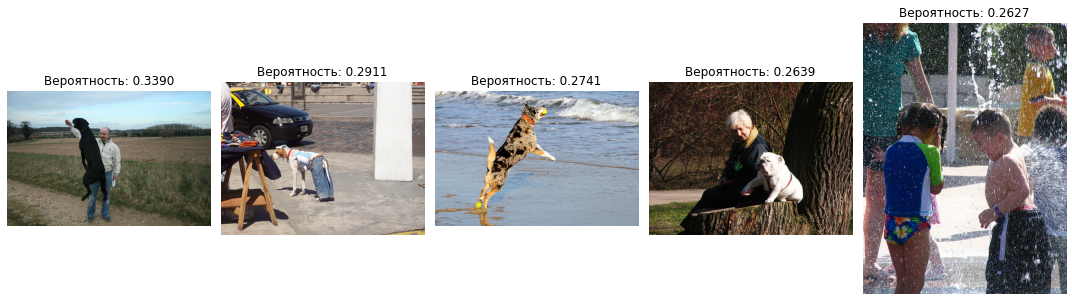

--------------------------------------------------
Запрос: A large gray bird begins to land in the water .


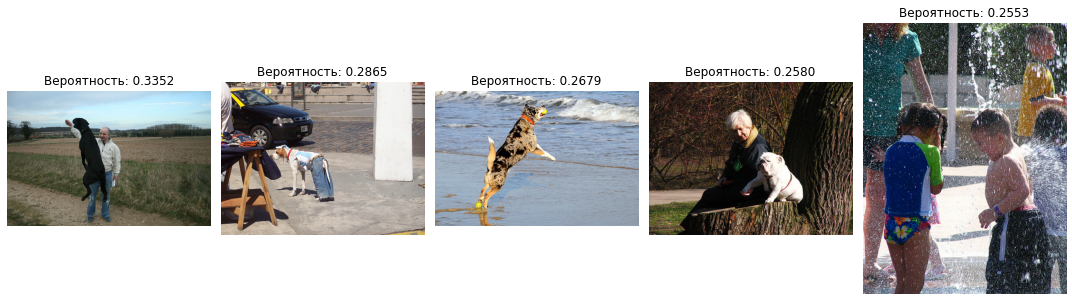

--------------------------------------------------
Запрос: A little girl with her hands in the air is sitting on a man 's back while he is laying on a blanket .
This image is unavailable in your country in compliance with local laws.
Запрос: While holding tight to the ball , the man in red socks is getting tackled .


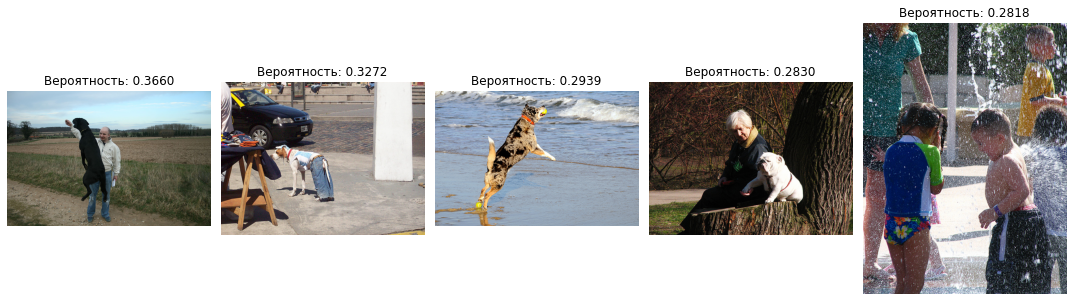

--------------------------------------------------
Запрос: An adult male wearing a backpack walks and looks to the left .


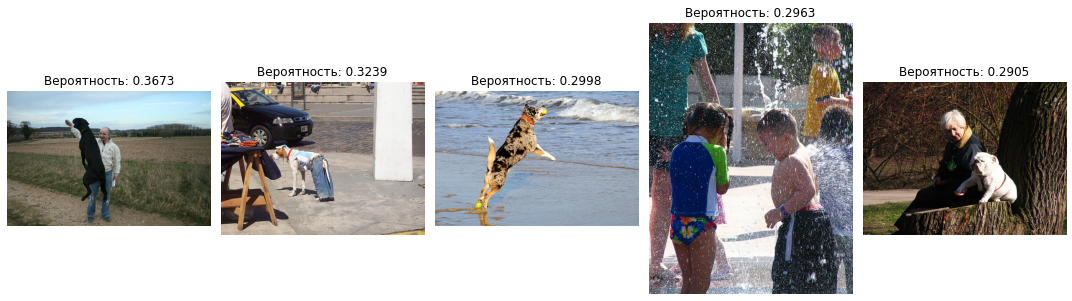

--------------------------------------------------
Запрос: Costumed performers stand onstage with their arms outstretched .


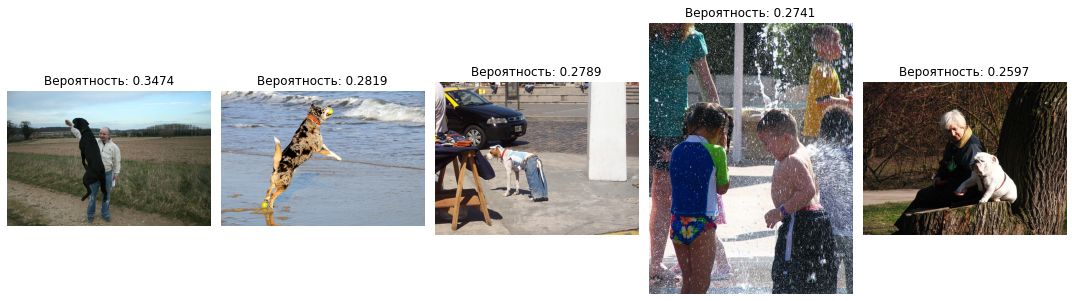

--------------------------------------------------
Запрос: Kids in bathing suits with water splashing around them .
This image is unavailable in your country in compliance with local laws.


In [39]:
# Обработка каждого запроса
for query_text in text_test:
    find_and_display_images(query_text, test_queries_df, improved_model, device, tokenizer, model, resnet50, top_k=5)

### Промежуточный вывод:

Как и предполагалось, количество изображений и описаний для обучения недостаточно. Нейросеть завышает данные по конкретным изображениям, иногда выдавая "корректный результат". Однако, функция работает, дисклеймер также выводится.

## Общий вывод:

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.


В ходе работы для векторизации изображений использовалась сеть ResNet50, а для текстовых эмбеддингов - BERT.

После объединения признаков и выделения целей (экспертные оценки схожести описания и картинок), было произведено исследование трех моделей для оценки схожести:

    LinearRegression
    Нейронная сеть

Наилучший результат показала нейронная сеть, с которой и проводилось тестирование.

В рамках теста была создана функция, возвращающя 5 наиболее походходящих под описание фотографий.

К сожалению, модель показывает низкую стабильность с точки зрения предоставления релевантных резульатов. Лишь в некоторых случаях в выдачу попадает верная картинка и, чуть чаще, попадают картинки связанные тематически. Есть вероятность, что предоставленный датасет содержит слишком мало данных для поиска хотябы одного дополнительного изображения, связанного с предоставленным описанием. Также улучшить показатели сети могло бы увеличение предоставленных данных как для тренировки, так и для тестирования.